In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Employee.csv", encoding="latin1")

In [3]:
#drop duplicates 
df.drop_duplicates(inplace = True)
df.reset_index(drop=True, inplace=True)


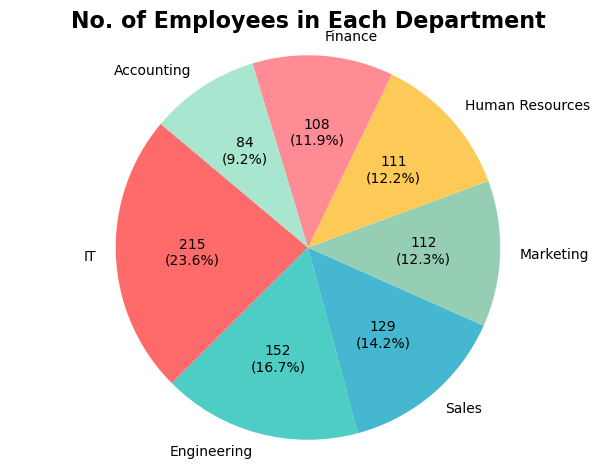

In [4]:
count_emp = df.groupby('Department')['EEID'].count().sort_values(ascending=False)

def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return f'{val}\n({pct:.1f}%)'
    return my_autopct
# Pie chart

plt.pie(count_emp.values,
        labels=count_emp.index,
        autopct=make_autopct(count_emp.values),
        startangle=140,
        colors=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57', '#FF8C94', '#A8E6CF'])

plt.title('No. of Employees in Each Department', fontweight='bold', fontsize=16)
plt.axis('equal')  # Equal aspect ratio makes pie a circle
plt.tight_layout()
plt.show()


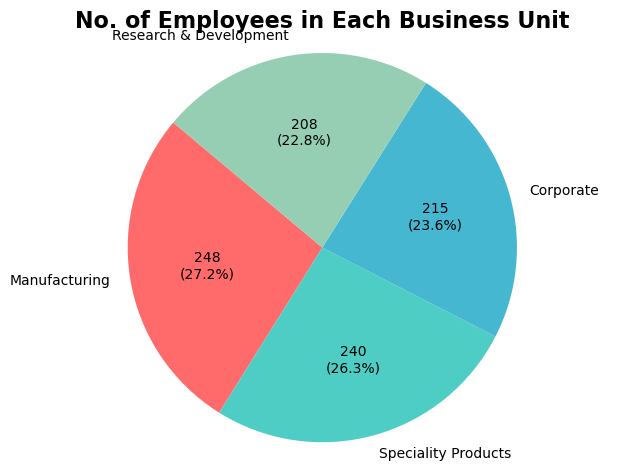

In [5]:
import matplotlib.pyplot as plt

count_emp = df.groupby('Business Unit')['EEID'].count().sort_values(ascending=False)

def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return f'{val}\n({pct:.1f}%)'
    return my_autopct

# Pie chart

plt.pie(count_emp.values,
        labels=count_emp.index,
        autopct=make_autopct(count_emp.values),
        startangle=140,
        colors=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57', '#FF8C94', '#A8E6CF'])

plt.title('No. of Employees in Each Business Unit', fontweight='bold', fontsize=16)
plt.axis('equal')  # Equal aspect ratio makes pie a circle
plt.tight_layout()
plt.show()


In [6]:
df['Annual_Salary_Clean'] = df['Annual Salary'].str.replace('$', '', regex=False)
df['Annual_Salary_Clean'] = df['Annual_Salary_Clean'].str.replace(',', '', regex=False)
df['Annual_Salary_Clean'] = pd.to_numeric(df['Annual_Salary_Clean'], errors='coerce')

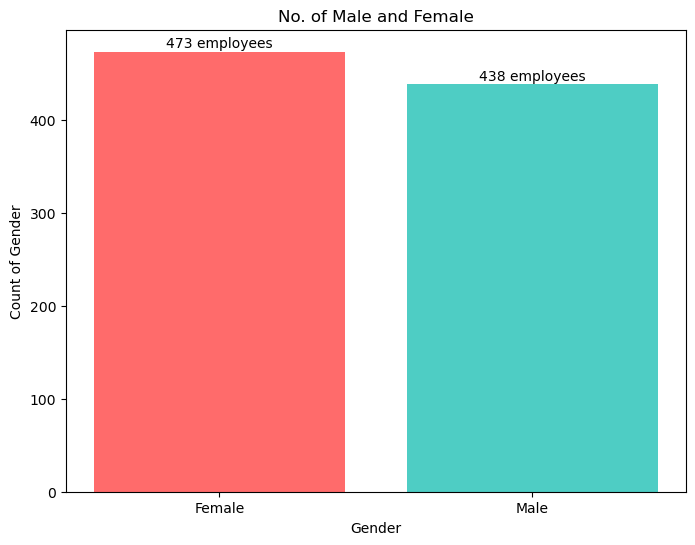

In [7]:
countss = df['Gender'].value_counts()

plt.figure(figsize=(8, 6))

# Create bars and capture them
bars = plt.bar(countss.index, countss.values, color=['#FF6B6B', '#4ECDC4'])

# Add labels above bars
for bar, gender, value in zip(bars, countss.index, countss.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,   # adjust "1" depending on your scale
             f'{value} employees',
             ha='center', va='bottom')

plt.xlabel('Gender')
plt.ylabel('Count of Gender')
plt.title('No. of Male and Female')
plt.show()


<Figure size 1400x800 with 0 Axes>

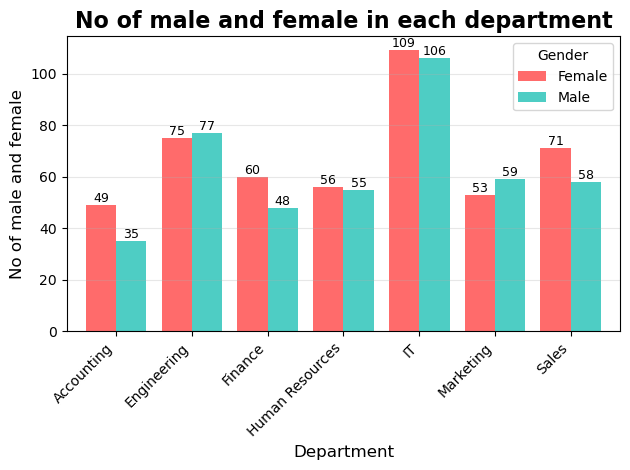

In [8]:
gen = df.groupby('Gender')['Department'].value_counts()

df_pivot = gen.unstack(level='Gender')

# Create grouped bar chart
plt.figure(figsize=(14, 8))
df_pivot.plot(kind='bar', width=0.8, color=['#FF6B6B', '#4ECDC4'])

plt.title('No of male and female in each department', fontsize=16, fontweight='bold')
plt.xlabel('Department', fontsize=12)
plt.ylabel('No of male and female', fontsize=12)
plt.legend(title='Gender', loc='upper right')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.0f', fontsize=9)

plt.tight_layout()
plt.show()



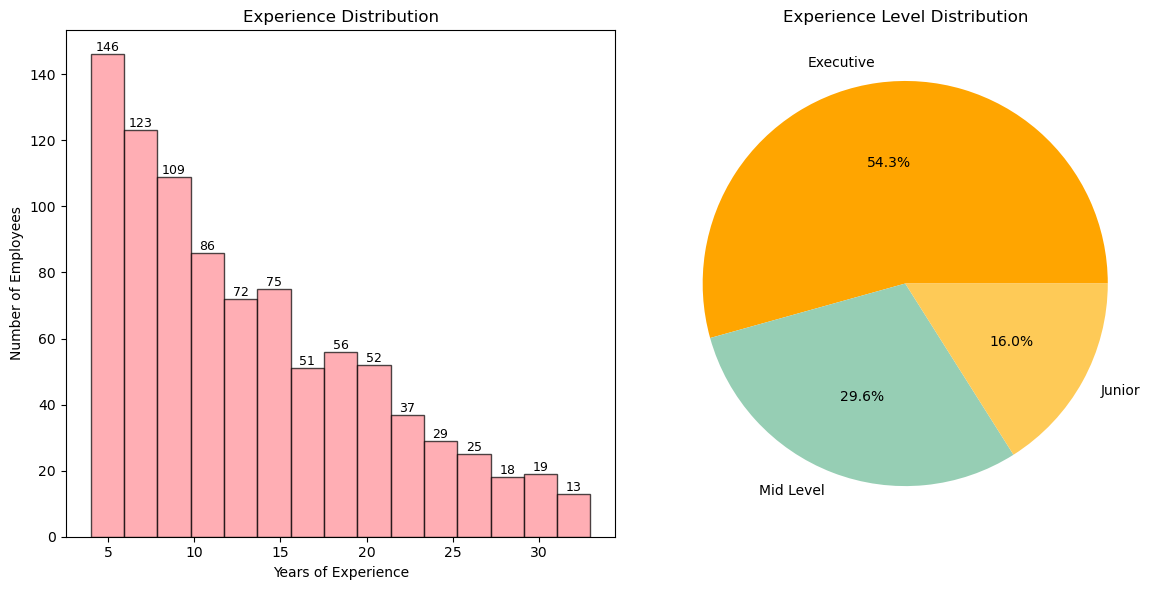

In [9]:
#experience distribution

plt.figure(figsize=(12, 6))

# Experience histogram
plt.subplot(1, 2, 1)
plt.hist(df['Experience'], bins=15, color='#FF8C94', alpha=0.7, edgecolor='black')
plt.title('Experience Distribution')
plt.xlabel('Years of Experience')
plt.ylabel('Number of Employees')
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.0f', fontsize=9)

# Experience by level
plt.subplot(1, 2, 2)
exp_level_counts = df['Exp lev'].value_counts()
plt.pie(exp_level_counts.values, labels=exp_level_counts.index, autopct='%1.1f%%',
        colors=['orange', '#96CEB4', '#FECA57'])
plt.title('Experience Level Distribution')
plt.tight_layout()
plt.show()


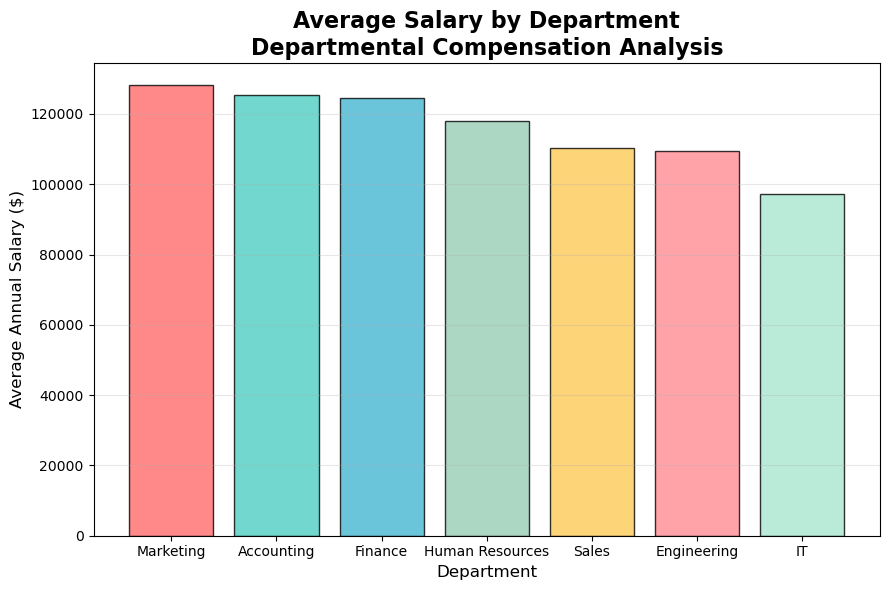

In [10]:
dept_avg_salary = df.groupby('Department')['Annual_Salary_Clean'].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57', '#FF8C94', '#A8E6CF']
bars = plt.bar(dept_avg_salary.index, dept_avg_salary.values, color=colors, alpha=0.8, edgecolor='black')

plt.title('Average Salary by Department\nDepartmental Compensation Analysis', fontsize=16, fontweight='bold')
plt.xlabel('Department', fontsize=12)
plt.ylabel('Average Annual Salary ($)', fontsize=12)



plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


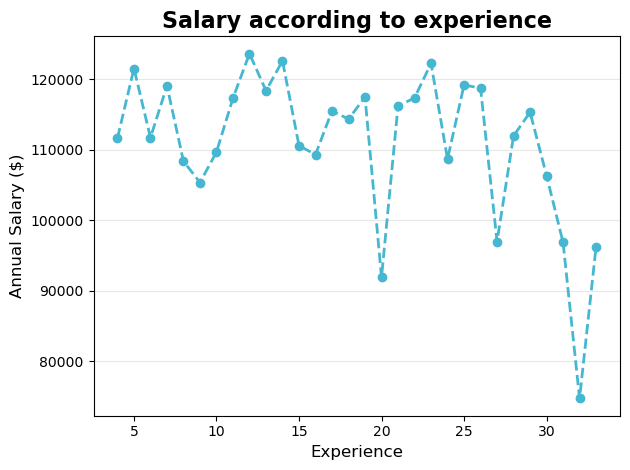

In [11]:
#salary vary by experience level
avg_sal=df.groupby('Experience')['Annual_Salary_Clean'].mean()
plt.plot(avg_sal.index, avg_sal.values,linestyle='--',linewidth=2, marker = 'o',color='#45B7D1')

plt.title('Salary according to experience', fontsize=16, fontweight='bold')
plt.xlabel('Experience', fontsize=12)
plt.ylabel('Annual Salary ($)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()


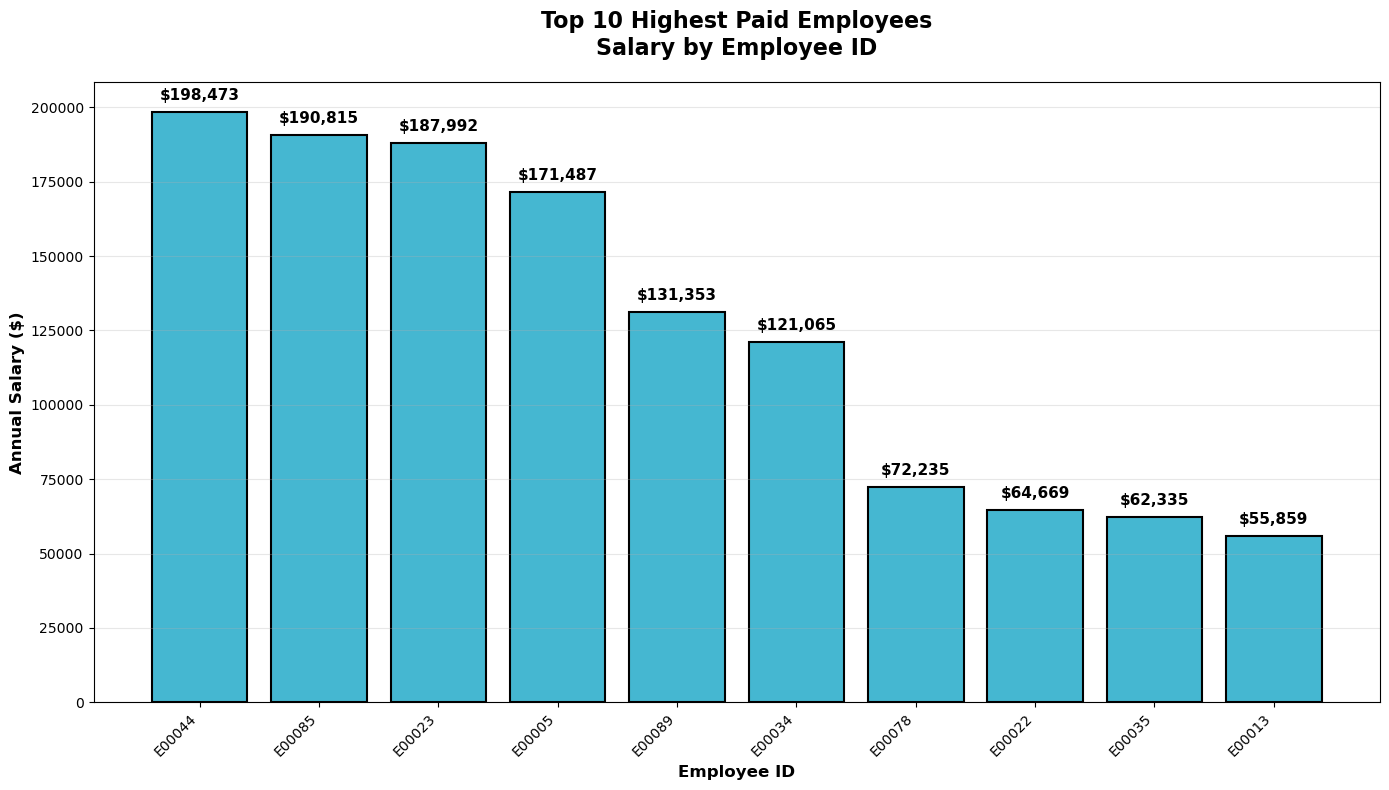

In [13]:


# Your existing code with labels added
top_10pay = df.groupby('EEID')['Annual_Salary_Clean'].max().head(10).sort_values(ascending=False)

plt.figure(figsize=(14, 8))  
bars = plt.bar(top_10pay.index, top_10pay.values, color='#45B7D1', edgecolor='black', linewidth=1.5)

# ADD SALARY LABELS ON TOP OF EACH BAR
for bar, value in zip(bars, top_10pay.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3000,
             f'${value:,.0f}', ha='center', va='bottom', 
             fontweight='bold', fontsize=11, color='black')

plt.xlabel('Employee ID', fontsize=12, fontweight='bold')
plt.ylabel('Annual Salary ($)', fontsize=12, fontweight='bold')
plt.title('Top 10 Highest Paid Employees\nSalary by Employee ID', 
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


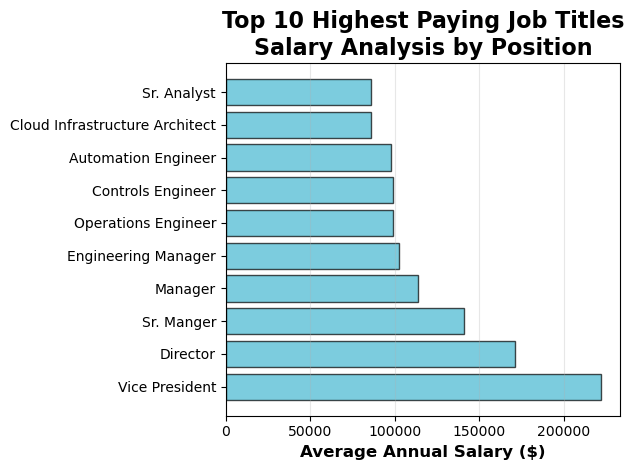

In [14]:
# Top 10 highest paying job titles
top_titles = df.groupby('Job Title')['Annual_Salary_Clean'].agg(['mean']).sort_values('mean', ascending=False).head(10)

bars = plt.barh(range(len(top_titles)), top_titles['mean'], color='#45B7D1', alpha=0.7,edgecolor='black')

plt.yticks(range(len(top_titles)), top_titles.index, fontsize=10)
plt.xlabel('Average Annual Salary ($)', fontsize=12,fontweight='bold')
plt.title('Top 10 Highest Paying Job Titles\nSalary Analysis by Position', fontsize=16, fontweight='bold')



plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

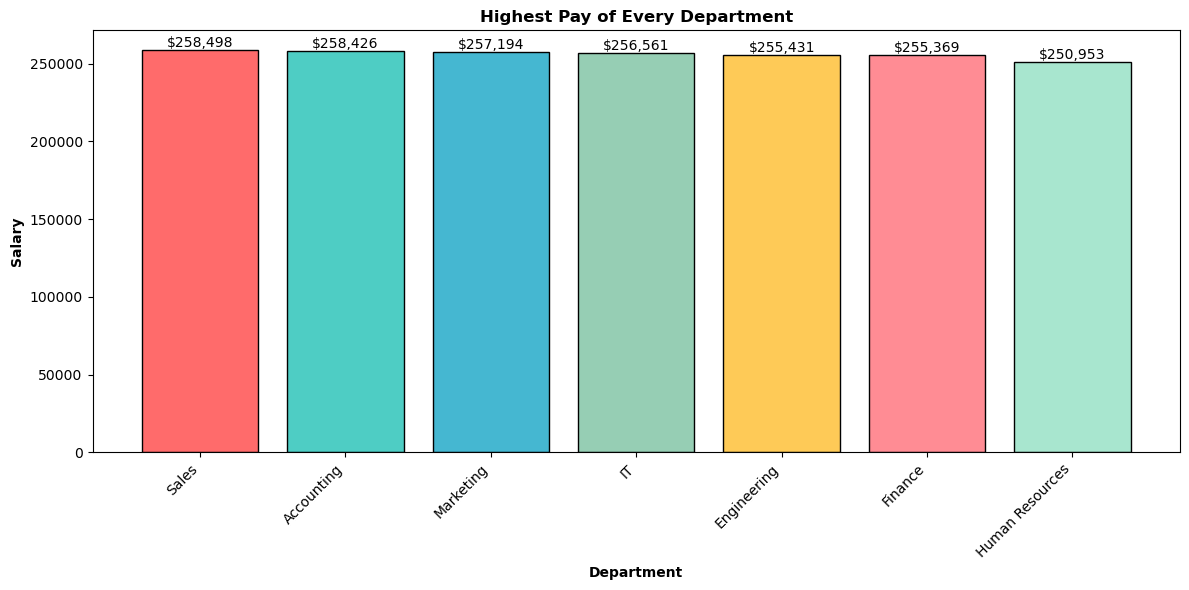

In [15]:
highest_paid = df.groupby('Department')['Annual_Salary_Clean'].max().sort_values(ascending=False)

plt.figure(figsize=(12, 6))

# Create bar plot and capture bars
bars = plt.bar(
    highest_paid.index,
    highest_paid.values,
    edgecolor='black',
    color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57', '#FF8C94', '#A8E6CF']
)

# Add text labels on top of bars
for bar, value in zip(bars, highest_paid.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,  
        f'${value:,.0f}',   
        ha='center', va='bottom'
    )
    
plt.title('Highest Pay of Every Department', fontweight='bold')
plt.xlabel('Department', fontweight='bold')
plt.ylabel('Salary', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


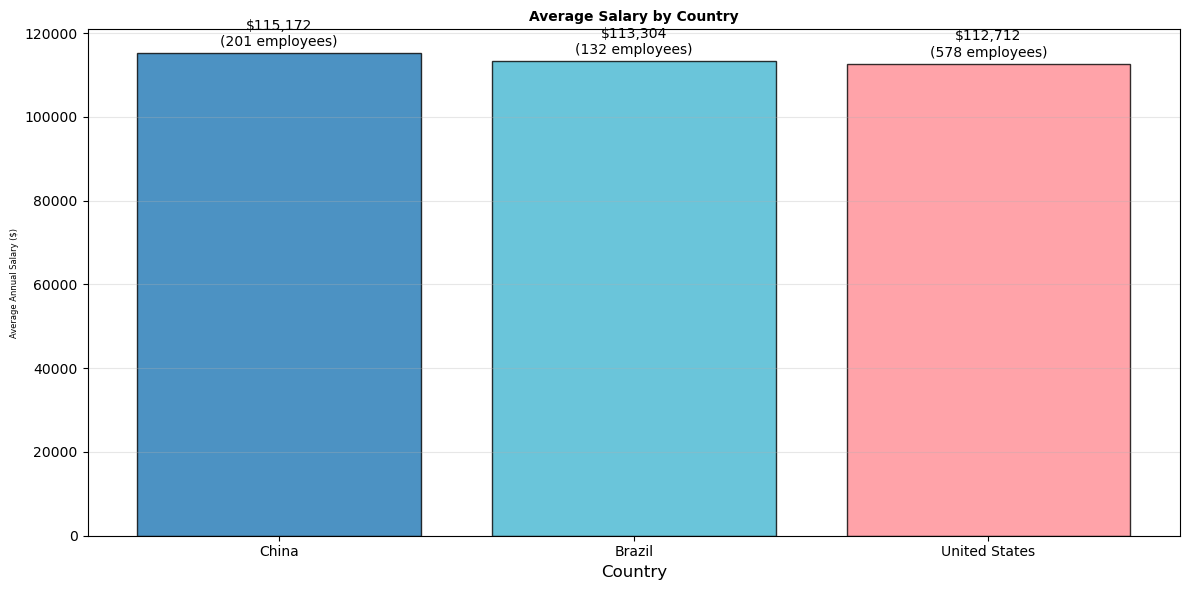

In [16]:
# Salary by country analysis
country_salary = df.groupby('Country')['Annual_Salary_Clean'].agg(['mean', 'count']).sort_values('mean', ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.bar(country_salary.index, country_salary['mean'], 
               color=['#1f77b4', '#45B7D1', '#FF8C94'], alpha=0.8, edgecolor='black')

plt.title('Average Salary by Country', fontsize=10, fontweight='bold')
plt.xlabel('Country', fontsize=12)
plt.ylabel('Average Annual Salary ($)', fontsize=6)


# Add value labels and employee counts
for i, (bar, country) in enumerate(zip(bars, country_salary.index)):
    mean_sal = country_salary.loc[country, 'mean']
    count = country_salary.loc[country, 'count']
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
             f'${mean_sal:,.0f}\n({count} employees)', ha='center', va='bottom')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [17]:
df.loc[df['Age'] < 30, 'Age_Group'] = 'Under 30'
df.loc[(df['Age'] >= 30) & (df['Age'] < 40), 'Age_Group'] = '30-39'
df.loc[(df['Age'] >= 40) & (df['Age'] < 50), 'Age_Group'] = '40-49'  
df.loc[(df['Age'] >= 50) & (df['Age'] < 60), 'Age_Group'] = '50-59'
df.loc[df['Age'] >= 60, 'Age_Group'] = '60+'

print("Age group: ")
print(df['Age_Group'].value_counts())

Age group: 
Age_Group
40-49       255
30-39       219
50-59       218
Under 30    114
60+         105
Name: count, dtype: int64


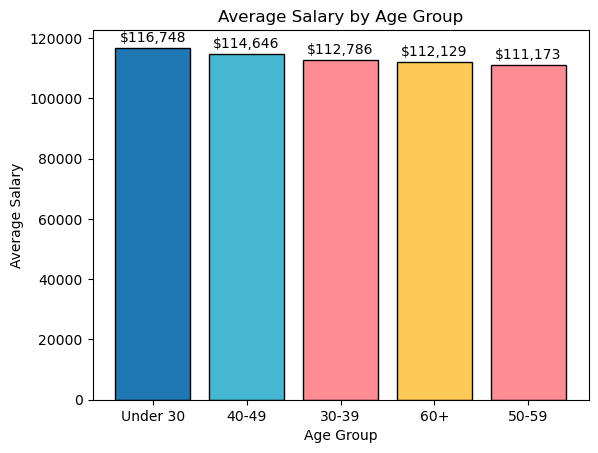

In [18]:
age_sal = df.groupby('Age_Group')['Annual_Salary_Clean'].agg(['mean']).sort_values('mean', ascending=False)



bars = plt.bar(age_sal.index, age_sal['mean'], color=['#1f77b4', '#45B7D1', '#FF8C94','#FECA57', '#FF8C94'],edgecolor='black')

# Add labels above bars
for bar, Age_Group in zip(bars, age_sal.index):
    mean_sal = age_sal.loc[Age_Group, 'mean']
   
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1000,  
             f'${mean_sal:,.0f}',
             ha='center', va='bottom')

plt.title("Average Salary by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Salary")
plt.show()


<Figure size 2000x1000 with 0 Axes>

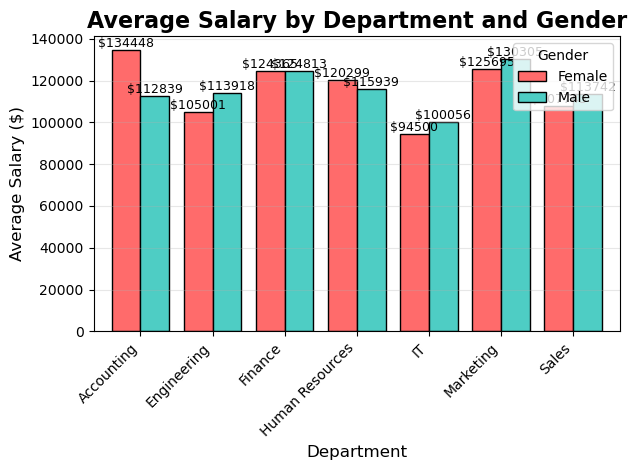

Pay Gap :
Gender                  Female           Male       Pay_Gap
Department                                                 
Accounting       134447.653061  112839.114286 -21608.538776
Engineering      105000.680000  113917.792208   8917.112208
Finance          124365.400000  124812.770833    447.370833
Human Resources  120299.267857  115938.963636  -4360.304221
IT                94499.972477  100055.660377   5555.687900
Marketing        125694.830189  130304.559322   4609.729133
Sales            107743.366197  113742.172414   5998.806217


In [19]:
avg_Sal_gen = df.groupby(['Department', 'Gender'])['Annual_Salary_Clean'].mean()

df_pivot = avg_Sal_gen.unstack(level='Gender')

# Create grouped bar chart
plt.figure(figsize=(20, 10))
df_pivot.plot(kind='bar', width=0.8, color=['#FF6B6B', '#4ECDC4'],edgecolor='black')

plt.title('Average Salary by Department and Gender', fontsize=16, fontweight='bold')
plt.xlabel('Department', fontsize=12)
plt.ylabel('Average Salary ($)', fontsize=12)
plt.legend(title='Gender', loc='upper right')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='$%.0f', fontsize=9)

plt.tight_layout()
plt.show()

#pay gap

print("Pay Gap :")

avg_salary = df.groupby(['Department', 'Gender'])['Annual_Salary_Clean'].mean().reset_index()


pivot_salary = avg_salary.pivot(index='Department', columns='Gender', values='Annual_Salary_Clean')


pivot_salary['Pay_Gap'] = (pivot_salary['Male']) - (pivot_salary['Female'])

print(pivot_salary)

max_pay_gap = pivot_salary['Pay_Gap'].max()

# Step 5: If you want the department(s) with max gap
dept_max_gap = pivot_salary[pivot_salary['Pay_Gap'] == max_pay_gap]


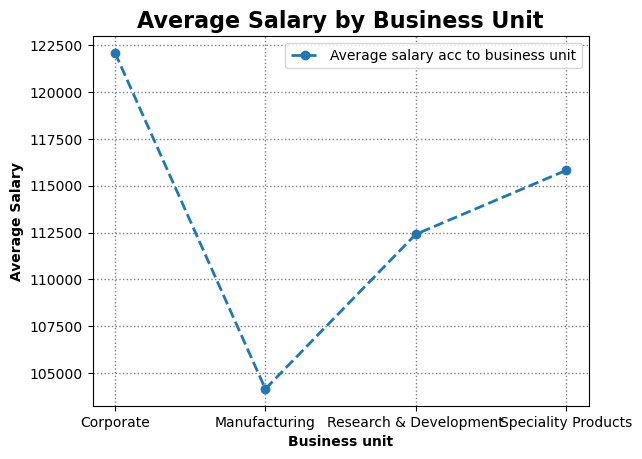

In [20]:
bus_emp=df.groupby('Business Unit')['Annual_Salary_Clean'].mean()

plt.plot(bus_emp.index,bus_emp.values,color='#1f77b4', linestyle='--',linewidth=2, marker = 'o',label='Average salary acc to business unit')
plt.title('Average Salary by Business Unit',fontsize=16, fontweight='bold')
plt.xlabel('Business unit',fontweight='bold')
plt.ylabel('Average Salary',fontweight='bold')
plt.legend(loc='upper right',fontsize=10)
plt.grid(color='grey',linestyle=':',linewidth=1)
# plt.xlin(1,4)
# plt.ylin(1000,5000),limit 


plt.show()